<a href="https://colab.research.google.com/github/sleacee/pet-projects-pandas/blob/main/%D0%B0%D0%BB%D0%BC%D0%B0%D0%B7%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Проведите первичное статистическое исследование количественных (минимальный, максимальный значения столбцов, медиана и т.п.) и категориальных признаков.
import pandas as pd

#загрузка данных
data = pd.read_csv("diamonds.csv")

#статистика для количественных признаков
quantitative_stats = data.describe()

#статистика для категориальных признаков
categorical_stats = data.describe(include=['object'])

print("Статистика для количественных признаков:")
print(quantitative_stats)

print("\nСтатистика для категориальных признаков:")
print(categorical_stats)

Статистика для количественных признаков:
         Unnamed: 0         carat         depth         table         price  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean   26970.500000      0.797940     61.749405     57.457184   3932.799722   
std    15571.281097      0.474011      1.432621      2.234491   3989.439738   
min        1.000000      0.200000     43.000000     43.000000    326.000000   
25%    13485.750000      0.400000     61.000000     56.000000    950.000000   
50%    26970.500000      0.700000     61.800000     57.000000   2401.000000   
75%    40455.250000      1.040000     62.500000     59.000000   5324.250000   
max    53940.000000      5.010000     79.000000     95.000000  18823.000000   

                  x             y             z  
count  53940.000000  53940.000000  53940.000000  
mean       5.731157      5.734526      3.538734  
std        1.121761      1.142135      0.705699  
min        0.000000      0.000000      0.000000

In [ ]:
#Определите наличие пропусков в данных. Предложите способы заполнения пропусков, но пока не заполняйте.

#проверка наличия пропусков в данных
missing_values = data.isnull().sum()

#вывод количества пропущенных значений для каждого признака
print("Количество пропущенных значений для каждого признака:")
print(missing_values)


Количество пропущенных значений для каждого признака:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


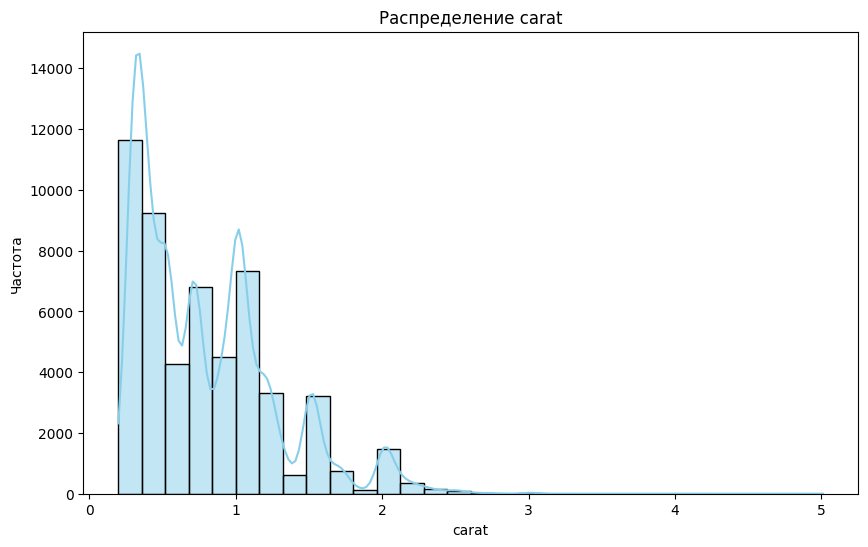

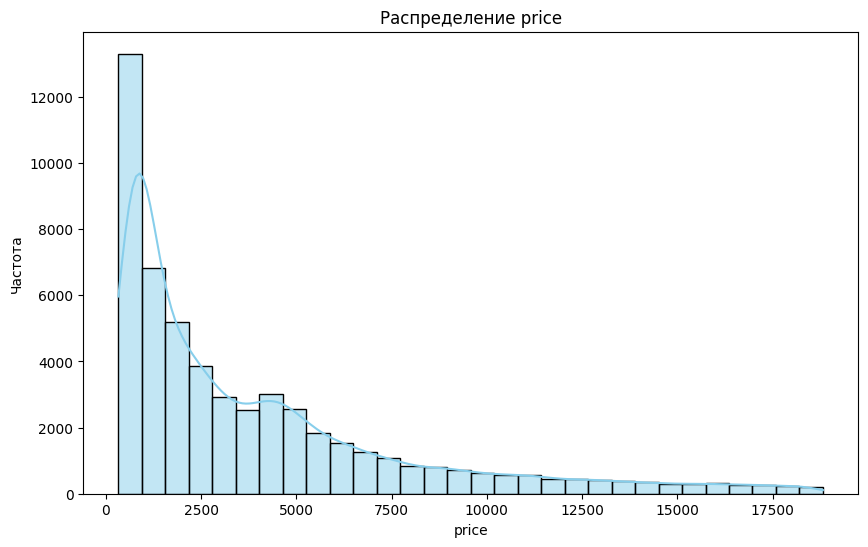

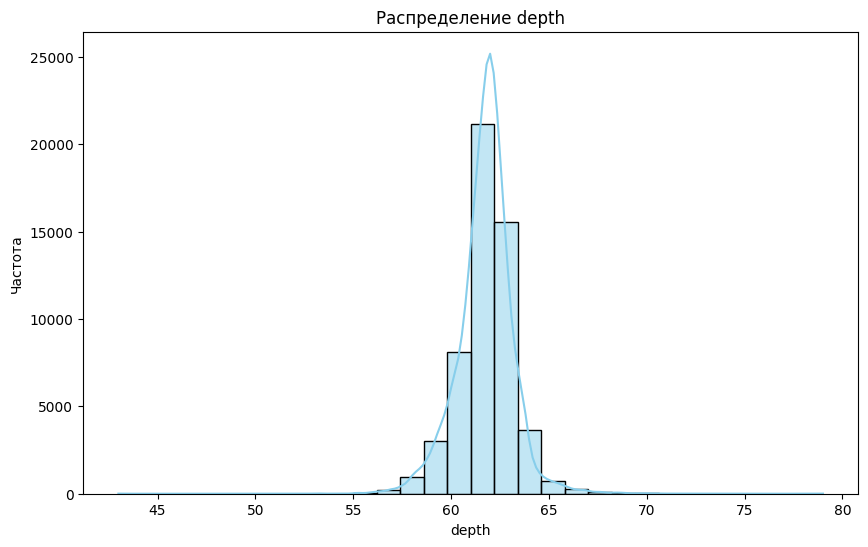

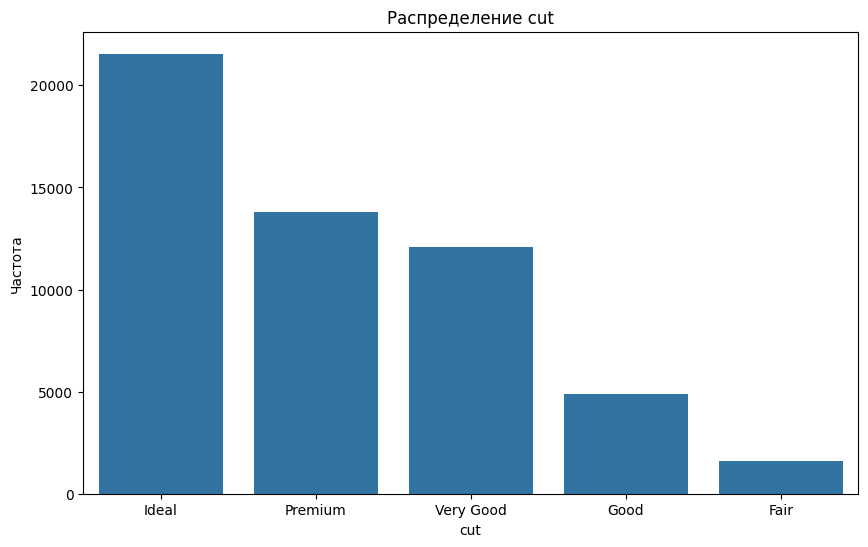

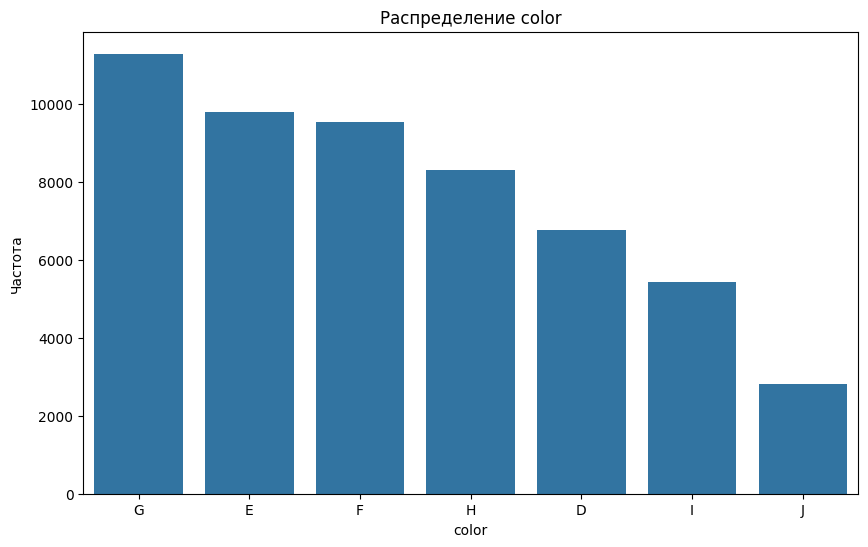

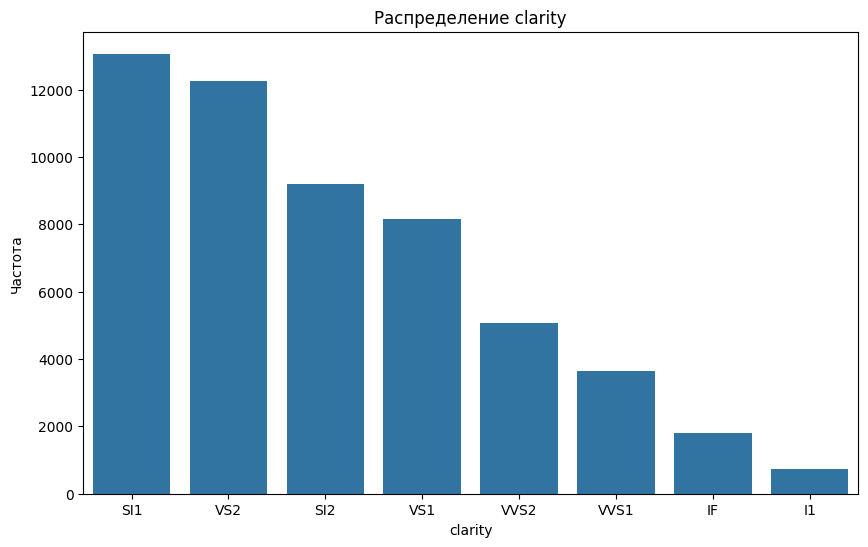

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


#гистограмма для количественных признаков
quantitative_features = ['carat', 'price', 'depth']
for feature in quantitative_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Частота')
    plt.show()


#гистограммы для категориальных признаков
categorical_features = ['cut', 'color', 'clarity']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=data[feature], order=data[feature].value_counts().index)
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Частота')
    plt.show()

In [ ]:
from scipy import stats
#количественные признаки
quantitative_columns = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

#рассчитаем Z-оценки для количественных признаков
z_scores = stats.zscore(data[quantitative_columns])

#определим выбросы (предположим, что выбросы находятся за пределами 3 стандартных отклонений)
threshold = 3
outliers = (abs(z_scores) > threshold).any(axis=1)

data_cleaned = data[~outliers]

print(f"Количество удаленных выбросов: {outliers.sum()}")

#описательная статистика для количественных признаков после удаления выбросов
quantitative_stats_cleaned = data_cleaned.describe()
print("Статистика для количественных признаков после удаления выбросов:")
print(quantitative_stats_cleaned)

Количество удаленных выбросов: 2350
Статистика для количественных признаков после удаления выбросов:
         Unnamed: 0         carat         depth         table         price  \
count  51590.000000  51590.000000  51590.000000  51590.000000  51590.000000   
mean   27007.824675      0.759933     61.752838     57.369137   3586.031847   
std    15728.274065      0.424983      1.269255      2.100018   3436.874161   
min        1.000000      0.200000     57.500000     51.000000    326.000000   
25%    13239.250000      0.390000     61.100000     56.000000    926.000000   
50%    27713.500000      0.700000     61.800000     57.000000   2303.500000   
75%    40758.750000      1.020000     62.500000     59.000000   5047.000000   
max    53940.000000      2.210000     66.000000     64.000000  15898.000000   

                  x             y             z  
count  51590.000000  51590.000000  51590.000000  
mean       5.657855      5.661272      3.494649  
std        1.057420      1.050383    

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

#загрузка данных
data = pd.read_csv("diamonds.csv")

#порядок категорий для Ordinal Encoding
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

#применение порядкового кодирования с помощью OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
data[['cut', 'color', 'clarity']] = ordinal_encoder.fit_transform(data[['cut', 'color', 'clarity']])

print("Данные после применения Ordinal Encoding:")
print(data.head())
print(data.describe())


Данные после применения Ordinal Encoding:
   Unnamed: 0  carat  cut  color  clarity  depth  table  price     x     y  \
0           1   0.23  4.0    5.0      1.0   61.5   55.0    326  3.95  3.98   
1           2   0.21  3.0    5.0      2.0   59.8   61.0    326  3.89  3.84   
2           3   0.23  1.0    5.0      4.0   56.9   65.0    327  4.05  4.07   
3           4   0.29  3.0    1.0      3.0   62.4   58.0    334  4.20  4.23   
4           5   0.31  1.0    0.0      1.0   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
         Unnamed: 0         carat           cut         color       clarity  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean   26970.500000      0.797940      2.904097      3.405803      3.051020   
std    15571.281097      0.474011      1.116600      1.701105      1.647136   
min        1.000000      0.200000      0.000000      0.000000      0.000000   
25%    13485.750000      0.400000 

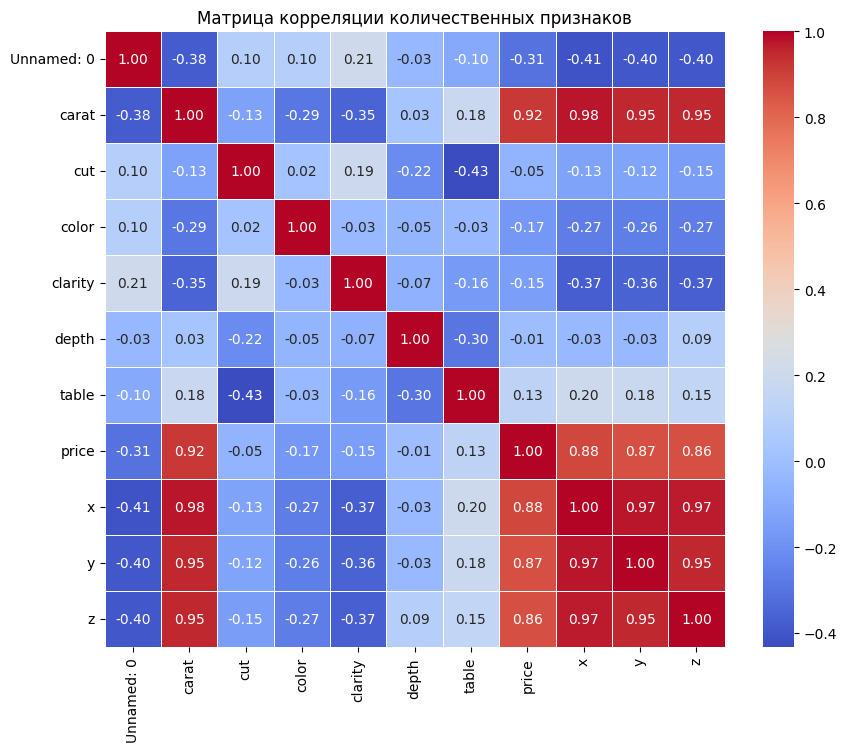

In [ ]:
#матрица корреляции
corr_matrix = data.corr()

#визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляции количественных признаков')
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

#применение нормализации
minmax_scaler = MinMaxScaler()
data[quantitative_columns] = minmax_scaler.fit_transform(data[quantitative_columns])

print("Данные после нормализации:")
print(data.head())

Данные после нормализации:
   Unnamed: 0     carat  cut  color  clarity     depth     table     price  \
0           1  0.006237  4.0    5.0      1.0  0.513889  0.230769  0.000000   
1           2  0.002079  3.0    5.0      2.0  0.466667  0.346154  0.000000   
2           3  0.006237  1.0    5.0      4.0  0.386111  0.423077  0.000054   
3           4  0.018711  3.0    1.0      3.0  0.538889  0.288462  0.000433   
4           5  0.022869  1.0    0.0      1.0  0.563889  0.288462  0.000487   

          x         y         z  
0  0.367784  0.067572  0.076415  
1  0.362197  0.065195  0.072642  
2  0.377095  0.069100  0.072642  
3  0.391061  0.071817  0.082704  
4  0.404097  0.073854  0.086478  


R²: 0.9060984889393997
MSE: 0.004362950485233457


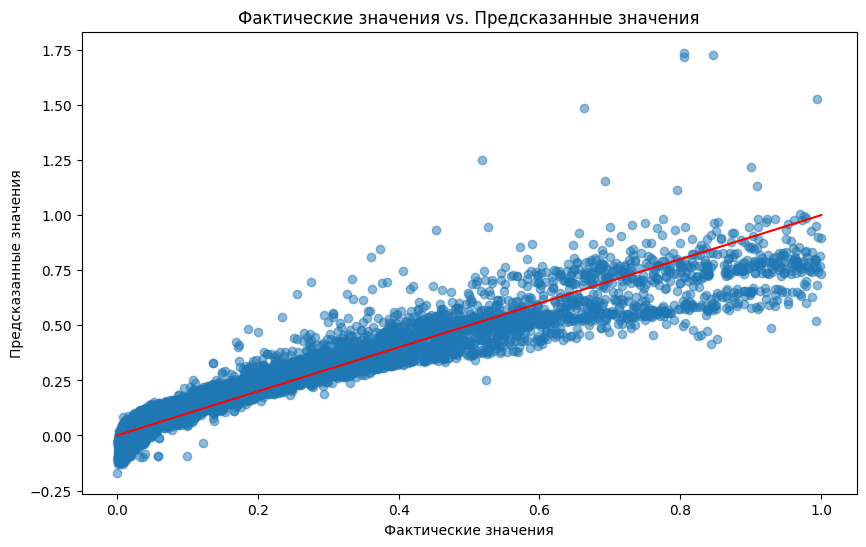

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
#определение признаков и целевой переменной
X = data.drop('price', axis=1)
y = data['price']

#разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#построение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

#предсказания на тестовой выборке
y_pred = model.predict(X_test)

#оценка модели
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R²: {r2}")
print(f"MSE: {mse}")

#график фактических и предсказанных значений
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Фактические значения vs. Предсказанные значения")
plt.plot([0,1], [0,1], color='red')
plt.show()


R² для полиномиальной регрессии: 0.9745473886228128
MSE для полиномиальной регрессии: 0.0011826059229961851


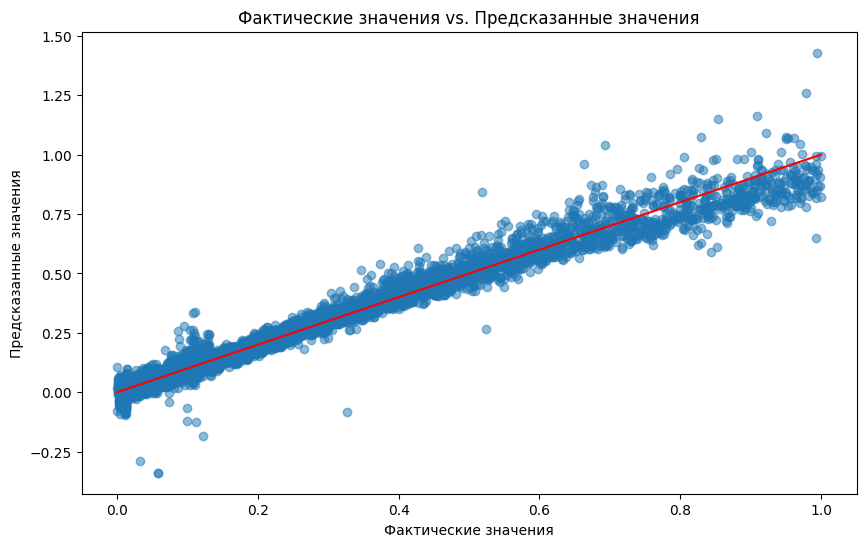

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

#создание модели полиномиальной регрессии
degree = 2  #степень полинома
polyreg = make_pipeline(PolynomialFeatures(degree), LinearRegression())

#обучение модели
polyreg.fit(X_train, y_train)

#предсказания на тестовой выборке
y_pred_poly = polyreg.predict(X_test)

#оценка модели
r2_poly = r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print(f"R² для полиномиальной регрессии: {r2_poly}")
print(f"MSE для полиномиальной регрессии: {mse_poly}")

#график фактических и предсказанных значений
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Фактические значения vs. Предсказанные значения")
plt.plot([0,1], [0,1], color='red')
plt.show()